<div style="color:blue">
    
# **General Instructions for the ML Coding Problems**

Please follow these instructions carefully to ensure a smooth evaluation process.

## **1. Notebook Submission**
- You **must** make a copy of this notebook and append your **full name** to the filename before submitting (e.g., `[OriginalNotebookName]_[YourName].ipynb`).
- Share  your notebook copy with inaio@acmindia.org [This is for your own safety so that you do not accidentally lose any changes while editing the notebook]
- After solving the questions, ensure you mention the correct URL of your  modified notebook in the test form
- Also answer questions on external resources used and link to LLM chats used for each problem in the main test form

## **2. Attempting the Questions**
- Carefully **read each problem statement** before attempting.
- **Attempt all parts** of each question.
- Each question is organized into the following parts
   - **DATA**, **TASK**, **HELPER CODE [Optional]** and **ANSWER**
- **Follow the function signatures** provided. Do not modify them.
- You only need to edit the cells in the **ANSWER** sections
- If required, you may also add other modules under **IMPORTS** and **INSTALLATION INSTRUCTIONS**
- Do not edit the other cells, especially those marked with **DO NOT MODIFY** which are meant for evaluation
- You may add new cells to the notebook with extra code as desired
  

## **3. Scoring Criteria**
Your score will be based on the following factors with distribution varying across each problem.
- **Soundness & Creativity** of your approach.  
  - Include a clear description and rationale of your solution methodology in the notebook (in markdown cells)
  - Solutions that showcase your understanding of data and ML will garner more points
- **Code Implementation & Readability**
  - Ensure your implementation is correct and works
  - Incomplete non-working code will be awarded  partial marks based on problem-wise rubric
  - In case you have a solution but are unsure about some aspect, you can define a function that solves that aspect and present the rest of the solution
  - Use comments to explain important parts of your code.
- **Performance of Your Model**:
  - Each task will be assessed based on specified performance metrics both on shared datasets and secret datasets
  - Different performance ranges will receive different scores.
  - Secret datasets used for last section will be shared along with the final results

**Points associated with cells are marked at the beginning of the cell**
    
## **4. Dataset Usage**
- **Only use the datasets provided** in this test.
- Do **not** use the provided test data set for training.
- Do **not** use external datasets for training or testing.
- If the submitted performance metrics cannot be reproduced with your code and original datasets, then you will lose all the points associated with model performance.


</div>

<div style="color:blue">
    
## Problem 7:  SmogCast: Forecasting Air Pollution in Bangalore & Delhi [14 pts]

Air pollution is a serious problem in India, particularly in cities like Bangalore and Delhi. The levels of particulate matter (PM 2.5) are influenced by traffic volume, temperature, and fuel prices. While traffic volume directly contributes to pollution, temperature has seasonal effects, and fuel prices can change driving behavior.

In this challenge, your task is to predict the particulate pollution level (PM 2.5) in two cities using historical data.

This problem has 4 questions (3 to be attempted, 4th one private INAIO evaluation)

-  **Q1: Smog Signals: What Drives Air Quality?** [4 pts]
-  **Q2: Build an Air Pollution Prediction Model** [5 pts]
-  **Q3: Test Air Pollution Prediction Model on Public Dataset** [3 pts]
-  **Q4: Test Air Pollution Prediction Model on Private Dataset** [2 pts] [NOT FOR STUDENTS TO ATTEMPT]

</div>

<div style="color:blue">
    
### INSTALLATION  

</div>

In [ ]:
!pip install pandas numpy scikit-learn scipy pygam matplotlib seaborn xgboost

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 720.1 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 522.0/522.0 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 3.9 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.13.1
    Uninstalling scipy-1.13.1:
      Successfully uninstalled scipy-1.13.1


<div style="color:blue">
    
### IMPORTS
</div>

In [ ]:
# EDIT: [O pts]
# You may add any other free python packages along with comments

# Data Types
from typing import Any

# Data handling
import pandas as pd  # Data manipulation and analysis
import numpy as np  # Numerical computations and array handling


# Machine Learning - Process
from sklearn.model_selection import train_test_split  # Splitting dataset
from sklearn.pipeline import Pipeline, make_pipeline # Combining multiple processing steps

# Machine Learning - Models
from sklearn.linear_model import LinearRegression  # Simple regression model
from sklearn.ensemble import RandomForestRegressor  # More powerful regression model
from xgboost import XGBRegressor
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Machine Learning - Feature Transformations
from sklearn.preprocessing import OneHotEncoder, StandardScaler # Feature transformations if needed
from sklearn.compose import ColumnTransformer #Transforming columns
from sklearn.preprocessing import PolynomialFeatures # Polynomial features


# Model evaluation
from sklearn.metrics import (
    mean_squared_error, # Mean squared Error
    r2_score,  # R² Score
    mean_absolute_percentage_error,  # MAPE
)


# Statistical Analysis
from scipy.stats import pearsonr  # Pearson correlation coefficient


# Visualization
import matplotlib.pyplot as plt  # Plotting graphs
import seaborn as sns  # Enhanced data visualization


**COPY DATA**

In [ ]:
# Copy data
!mkdir /content/data
!wget https://raw.githubusercontent.com/inaiogit/stage2test/main/test/air_pollution_test_public.csv
!wget https://raw.githubusercontent.com/inaiogit/stage2test/main/test/air_pollution_train.csv
!mv air_pollution_test_public.csv air_pollution_train.csv data/

mkdir: cannot create directory ‘/content/data’: File exists
--2025-03-02 06:32:28--  https://raw.githubusercontent.com/inaiogit/stage2test/main/test/air_pollution_test_public.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 40211 (39K) [text/plain]
Saving to: ‘air_pollution_test_public.csv’

air_pollution_test_ 100%[===================>]  39.27K  --.-KB/s    in 0.05s   

2025-03-02 06:32:29 (857 KB/s) - ‘air_pollution_test_public.csv’ saved [40211/40211]

--2025-03-02 06:32:29--  https://raw.githubusercontent.com/inaiogit/stage2test/main/test/air_pollution_train.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|18

<div style="color:blue">
    
### **Q1: Smog Signals: What Drives Air Quality?** [4 pts]

Before building a predictive model, it is  crucial to explore the data to uncover patterns, relationships, and anomalies
to build an appropriate model. This is especially important for time-series data.


</div>


<div style="color:blue">

### DATA

You are provided with a **historical dataset** containing weekly observations of **air pollution, temperature, traffic volume, and fuel prices** for two major Indian cities:

- **`air_pollution_train_path`**: historical data (each row corresponds to entries of a particular week)

**Columns**
- **`Week`** - Week index starting from the first week of observation (across multiple years)
- **`Particulate_Level_Bangalore`** – PM2.5 pollution level in Bangalore *(Target Variable)*
- **`Temperature_Bangalore`** – Weekly average temperature in Bangalore (°C)
- **`Avg_Vehicle_Volume_Bangalore`** – Number of vehicles on Bangalore roads per week
- **`Particulate_Level_Delhi`** – PM2.5 pollution level in Delhi *(Target Variable)*
- **`Temperature_Delhi`** – Weekly average temperature in Delhi (°C)
- **`Avg_Vehicle_Volume_Delhi`** – Number of vehicles on Delhi roads per week
- **`Petrol_Price`** – Weekly fuel price per liter (INR), common to both cities



</div>


In [ ]:
# Training datasets
air_pollution_train_path = "data/air_pollution_train.csv"  # historical air pollution and related factors data



<div style="color:blue">
    
### TASK

Analyze the data and record your observations below:
   - (a) Is there a correlation between Particulate_Level_Bangalore and Particulate_Level_Delhi ? **(Answer Yes/No and explain)**
   - (b) What is the relationship between Particulate Level, Temperate and Average Vehicle Volume in a particular city ? **Justify with observations**   
   - (c) How does Petrol Price impact Particulate Levels? **Justify with observations**   

</div>


<div style="color:red">
    
### ANSWER

</div>

In [ ]:
# EDIT: [1 pt]
# Add your data exploration code here
data = pd.read_csv(air_pollution_train_path)
data.head()

,Week,Particulate_Level_Bangalore,Temperature_Bangalore,Avg_Vehicle_Volume_Bangalore,Particulate_Level_Delhi,Temperature_Delhi,Avg_Vehicle_Volume_Delhi,Petrol_Price
0,1,203.696673,23.884332,96203.303977,226.544283,10.777520,115113.276472,82.353010
1,2,208.125742,22.817158,98880.549229,229.993222,12.048196,115914.966287,83.089090
2,3,212.705955,21.644363,105168.012767,229.692853,12.432674,115896.557377,82.694740
3,4,199.623883,24.049248,106155.758951,236.570809,12.885539,123828.331536,84.657543
4,5,215.323311,21.493527,100747.781568,246.417325,12.248691,120127.730839,83.960813


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Week                          200 non-null    int64  
 1   Particulate_Level_Bangalore   200 non-null    float64
 2   Temperature_Bangalore         200 non-null    float64
 3   Avg_Vehicle_Volume_Bangalore  200 non-null    float64
 4   Particulate_Level_Delhi       200 non-null    float64
 5   Temperature_Delhi             200 non-null    float64
 6   Avg_Vehicle_Volume_Delhi      200 non-null    float64
 7   Petrol_Price                  200 non-null    float64
dtypes: float64(7), int64(1)
memory usage: 12.6 KB


plt.scatter(data.Particulate_Level_Bangalore,data.Particulate_Level_Delhi)
plt.show()

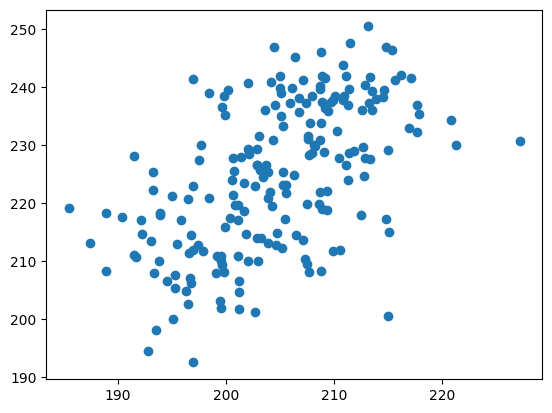

In [ ]:
plt.scatter(data.Particulate_Level_Bangalore,data.Particulate_Level_Delhi)
plt.show()

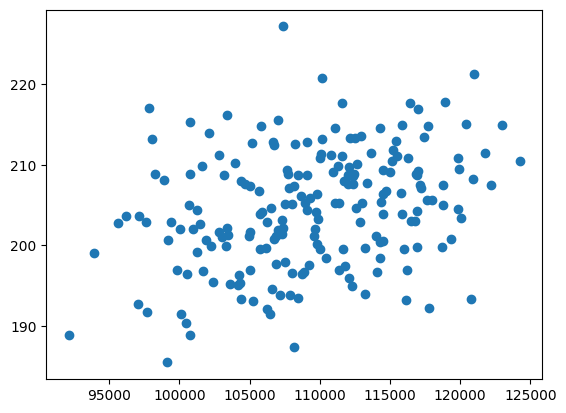

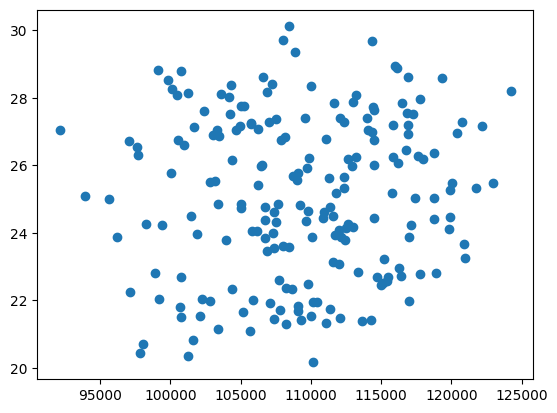

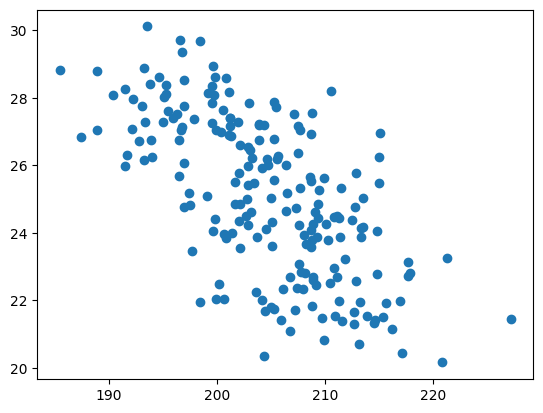

In [ ]:
plt.scatter(data.Avg_Vehicle_Volume_Bangalore,data.Particulate_Level_Bangalore)
plt.show()

plt.scatter(data.Avg_Vehicle_Volume_Bangalore,data.Temperature_Bangalore)
plt.show()

plt.scatter(data.Particulate_Level_Bangalore,data.Temperature_Bangalore)
plt.show()

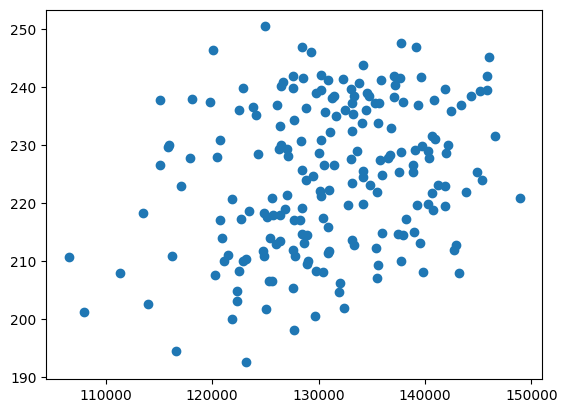

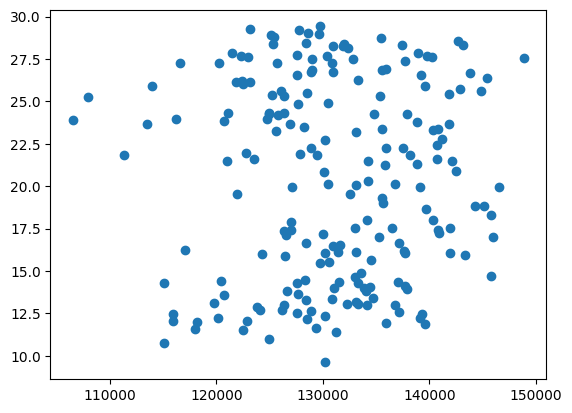

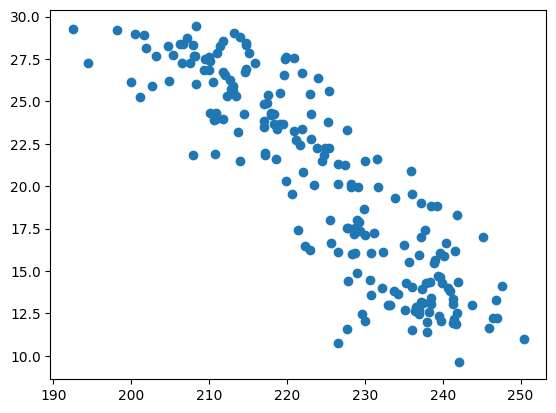

In [ ]:
plt.scatter(data.Avg_Vehicle_Volume_Delhi,data.Particulate_Level_Delhi)
plt.show()

plt.scatter(data.Avg_Vehicle_Volume_Delhi,data.Temperature_Delhi)
plt.show()

plt.scatter(data.Particulate_Level_Delhi,data.Temperature_Delhi)
plt.show()

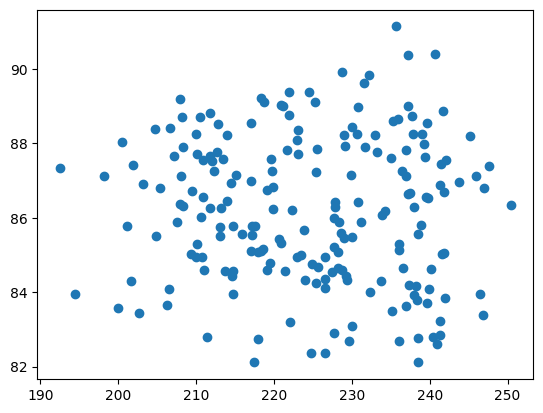

In [ ]:
plt.scatter(data.Particulate_Level_Delhi,data.Petrol_Price)
plt.show()

####
**EDIT: [3 pts]**

#### (a) Is there a correlation between Particulate_Level_Bangalore and Particulate_Level_Delhi ? [1 pt]
- Yes
- Reasons: As we can see from the plot, there seems to be a linear relation between the two

#### (b) Comment on the pair-wise  relationships between Particulate Level, Temperature and Average Vehicle Volume in a particular city ? [1 pt]
- Relationship: +ve between vehicle volume and particulate level, -ve between particulate level and temperature
- Justification: Clear from the plots shown above

#### (c) How does Petrol Price impact Particulate Levels?   [1 pt]
- Relationship: No relation
- Justification: Clear from the plot shown above


## **Q2: Build an Air Pollution Forecasting Model** [5 pts]

<div style="color:blue">

### DATA
Use the same  **historical dataset** containing weekly observations of **air pollution, temperature, traffic volume, and fuel prices** from Q1

- **`air_pollution_train_path`**: historical data (each row corresponds to entries of a particular week

</div>


In [ ]:
# Training datasets
air_pollution_train_path = "data/air_pollution_train.csv"  # historical air pollution and related factors data



<div style="color:blue">
    
### TASK

Create two functions **learn_air_pollution_forecast_model** and **forecast_air_pollution** as per the signatures defined below.  
If you scroll down, you will see cells with the skeletal code that you need to flesh out.

---

### **Function 1: `learn_air_pollution_forecast_model`**

```python
def learn_air_pollution_forecast_model(
    train_file_path: str,
    lead_time: int
) -> dict:
    """
    Loads a dataset from a CSV file, processes it to align features with future target values at the given lead time,
    and trains a machine learning model to predict air pollution (PM2.5) levels for Bangalore and Delhi.

    Parameters:
    - train_file_path (str): Path to the CSV file containing historical weekly data with:
        - "Week" - Week index starting from the first week of observation (across multiple years)
        - "Particulate_Level_Bangalore" (numerical, target variable)
        - "Temperature_Bangalore" (numerical, in Celsius)
        - "Avg_Vehicle_Volume_Bangalore" (numerical)
        - "Particulate_Level_Delhi" (numerical, target variable)
        - "Temperature_Delhi" (numerical, in Celsius)
        - "Avg_Vehicle_Volume_Delhi" (numerical)
        - "Petrol_Price" (numerical, INR per liter, common to both cities)

    - lead_time (int): The number of weeks ahead the model should predict (e.g., 6 weeks ahead).

    Returns:
    - model (dict): A dictionary where the key is the city name and the value is the model trained for that city.
    ({"Bangalore": model_1, "Delhi": model_2 })
    """
```
---

### **Function 2: `forecast_air_pollution`**

```python
def forecast_air_pollution(
    model: dict,
    past_df: pd.DataFrame,
    future_observed_df: pd.DataFrame,
    lead_time: int
) -> pd.DataFrame:
    """
    Predicts air pollution (PM2.5) levels for Bangalore and Delhi at a future date, given a specified lead time.

    Parameters:
    - model (dict): A dictionary where the key is the city name and the value is the model trained for that city.
    - past_df (pd.DataFrame): Past weekly data with past PM2.5 levels, temperature, vehicle volume, and petrol prices.
    - future_observed_df (pd.DataFrame): Known future values for:
        - "Week" - Week index starting from the first week of observation (across multiple years)
        - "Petrol_Price" (future fuel price, known in advance)
    - lead_time (int): The number of time steps ahead to predict (e.g., 6 weeks ahead from the last available data point).

    Returns:
    - pd.DataFrame: A DataFrame with predicted values for:
        - "Particulate_Level_Bangalore"
        - "Particulate_Level__Delhi"
    """

```


**Hints:**
- Load and explore the data (you already did a bit of this in Q1)
- Choose an appropriate time series model based on what you observe
- Train a model, analyze performance, and iterate"

</div>

<div style="color:blue">
    
### HELPER CODE
</div>

In [ ]:
# HELPER CODE
# You may choose to use or modify any of the below code in your solution, but it is NOT mandatory

def create_lag_features(
    df: pd.DataFrame,
    target_columns: list,
    lags: int
) -> pd.DataFrame:
    """
    Creates lag features for time-series forecasting.

    Parameters:
    - df (pd.DataFrame): The input dataframe containing time-series data.
    - target_columns (list): List of target variable column names (e.g., ["Particulate_Level_Bangalore"]).
    - lags (int): Number of past time steps (lags) to include.

    Returns:
    - pd.DataFrame: A dataframe with added lag features.

    Example Usage:
    ```python
    df = create_lag_features(df, target_columns=["Particulate_Level_Bangalore"], lags=4)
    ```
    """
    df = df.copy()

    for col in target_columns:
        for lag in range(1, lags + 1):
            df[f"{col}_Lag{lag}"] = df[col].shift(lag)

    df.dropna(inplace=True)  # Remove rows with NaN values due to shifting
    return df

def create_rolling_average_features(
    df: pd.DataFrame,
    target_columns: list,
    window_size: int
) -> pd.DataFrame:
    """
    Creates rolling average features to capture trends in time-series data.

    Parameters:
    - df (pd.DataFrame): The input dataframe containing time-series data.
    - target_columns (list): List of target variable column names (e.g., ["Particulate_Level_Bangalore"]).
    - window_size (int): The number of time steps to compute the rolling average.

    Returns:
    - pd.DataFrame: A dataframe with added rolling average features.

    Example Usage:
    ```python
    df = create_rolling_average_features(df, target_columns=["Particulate_Level_Bangalore"], window_size=4)
    ```
    """
    df = df.copy()

    for col in target_columns:
        df[f"{col}_MA{window_size}"] = df[col].rolling(window=window_size).mean()

    df.dropna(inplace=True)  # Remove rows with NaN values due to rolling window
    return df


def train_xgboost_regressor(
    df: pd.DataFrame,
    target_column: str,
    feature_columns: list,
    test_size: float = 0.2,
    n_estimators: int = 100,
    learning_rate: float = 0.1,
    max_depth: int = 5
) -> tuple:
    """
    Trains an XGBoost regression model for time-series forecasting.

    Parameters:
    - df (pd.DataFrame): The input dataframe containing features and target variable.
    - target_column (str): The name of the target variable (e.g., "Particulate_Level_Bangalore").
    - feature_columns (list): List of feature column names (e.g., lag features, temperature, petrol price).
    - test_size (float): Proportion of data used for testing (default = 0.2). If 0, the entire dataset is used for training.
    - n_estimators (int): Number of trees in the XGBoost model (default = 100).
    - learning_rate (float): Learning rate for gradient boosting (default = 0.1).
    - max_depth (int): Maximum depth of trees (default = 5).

    Returns:
    - tuple:
        - trained_model (XGBRegressor): The trained XGBoost model.
        - X_test (pd.DataFrame or None): The test set features (None if test_size=0).
        - y_test (pd.Series or None): The actual target values for the test set (None if test_size=0).
        - predictions (np.ndarray or None): The predicted values (None if test_size=0).
        - RMSE (float or None): Root Mean Squared Error of the model (None if test_size=0).

    Example Usage:
    ```python
    model, X_test, y_test, predictions, rmse = train_xgboost_forecaster(
        df, target_column="Particulate_Level_Bangalore", feature_columns=["Temperature_Bangalore", "Petrol_Price"], test_size=0
    )
    ```
    """
    df = df.copy()
    df.dropna(inplace=True)  # Drop missing values

    # If test_size is 0, use the entire dataset for training
    if test_size == 0:
        X_train, y_train = df[feature_columns], df[target_column]
        X_test, y_test, predictions, rmse = None, None, None, None
    else:
        X_train, X_test, y_train, y_test = train_test_split(
            df[feature_columns], df[target_column], test_size=test_size, random_state=42
        )

    # Train XGBoost model
    model = XGBRegressor(n_estimators=n_estimators, learning_rate=learning_rate, max_depth=max_depth)
    model.fit(X_train, y_train)

    # Make predictions if test_size > 0
    if test_size > 0:
        predictions = model.predict(X_test)
        rmse = np.sqrt(mean_squared_error(y_test, predictions))
    else:
        predictions, rmse = None, None

    return model, X_test, y_test, predictions, rmse


def generate_forecast_timeseries_xgboost(
    model: XGBRegressor,
    past_df: pd.DataFrame,
    future_observed_df: pd.DataFrame,
    target_column: str,
    feature_past: list,
    feature_future_observed: list,
    feature_future_not_observed: list,
    lead_time: int
) -> pd.DataFrame:
    """
    Generates time-series forecasts using a trained XGBoost model.

    Parameters:
    - model (XGBRegressor): The trained XGBoost model.
    - past_df (pd.DataFrame): Historical data used to generate lag features.
    - future_observed_df (pd.DataFrame): DataFrame containing known future values for exogenous variables.
    - target_column (str): Name of the target variable to predict (e.g., "Sales", "PM2.5").
    - feature_past (list): List of features derived from past values (e.g., lag features, rolling averages).
    - feature_future_observed (list): List of features with known future values (e.g., fuel price, planned events).
    - feature_future_not_observed (list): List of features not yet observed but estimated (e.g., forecasted traffic volume).
    - lead_time (int): Number of time steps ahead to predict.

    Returns:
    - pd.DataFrame: A DataFrame containing forecasted values for the specified lead_time.

    Example Usage:
    ```python
    forecast_df = generate_forecast_timeseries_xgboost(
        model, past_df, future_df, target_column="Sales",
        feature_past=["Sales_Lag1", "Sales_Lag2"],
        feature_future_observed=["Marketing_Spend", "Holiday"],
        feature_future_not_observed=["Predicted_Traffic"],
        lead_time=6
    )
    print(forecast_df)
    ```
    """
    # Ensure past data includes necessary lag features
    past_df = past_df.copy()

    # Select the most recent past observation
    forecast_input = past_df.iloc[-1:].copy()

    # Merge with known future observed data
    forecast_input.update(future_observed_df)

    # Ensure correct feature selection
    all_features = feature_past + feature_future_observed + feature_future_not_observed
    forecast_input = forecast_input[all_features]

    # Generate predictions iteratively for the specified lead time
    predictions = []

    for _ in range(lead_time):
        pred = model.predict(forecast_input)
        predictions.append(pred[0])  # Assuming a single target variable

        # Shift data forward for iterative forecasting
        forecast_input[f"{target_column}_Lag1"] = pred[0]  # Use prediction as next lag
        for lag in range(2, len(feature_past) + 1):  # Shift other lag values
            forecast_input[f"{target_column}_Lag{lag}"] = forecast_input[f"{target_column}_Lag{lag-1}"]

    # Convert results into a DataFrame
    forecast_df = pd.DataFrame(predictions, columns=[f"Predicted_{target_column}"])
    forecast_df.index.name = "Time Steps Ahead"

    return forecast_df

def generate_forecast_timeseries_sarima(
    past_df: pd.DataFrame,
    future_observed_df: pd.DataFrame,
    target_column: str,
    feature_past: list,
    feature_future_observed: list,
    feature_future_not_observed: list,
    lead_time: int,
    sarima_order: tuple = (1, 1, 1),
    seasonal_order: tuple = (1, 1, 1, 12)
) -> pd.DataFrame:
    """
    Generates time-series forecasts using a SARIMAX model.

    Parameters:
    - past_df (pd.DataFrame): Historical data used for model fitting.
    - future_observed_df (pd.DataFrame): DataFrame containing known future values for exogenous variables.
    - target_column (str): The target variable to predict.
    - feature_past (list): Features derived from past values (e.g., lag features).
    - feature_future_observed (list): Features with known future values (e.g., fuel prices, holidays).
    - feature_future_not_observed (list): Features not yet observed but estimated (e.g., predicted traffic volume).
    - lead_time (int): Number of time steps ahead to forecast.
    - sarima_order (tuple): The (p, d, q) order for SARIMA (default = (1,1,1)).
    - seasonal_order (tuple): The (P, D, Q, s) seasonal order (default = (1,1,1,12) for monthly data).

    Returns:
    - pd.DataFrame: A DataFrame containing forecasted values for the specified lead_time.

    Example Usage:
    ```python
    forecast_df = generate_forecast_timeseries_sarima(
        past_df, future_df, target_column="Sales",
        feature_past=["Sales_Lag1", "Sales_Lag2"],
        feature_future_observed=["Marketing_Spend", "Holiday"],
        feature_future_not_observed=["Predicted_Traffic"],
        lead_time=6
    )
    print(forecast_df)
    ```
    """
    # Prepare past and future feature data
    exog_past = past_df[feature_future_observed + feature_future_not_observed] if feature_future_observed or feature_future_not_observed else None
    exog_future = future_observed_df[feature_future_observed + feature_future_not_observed] if feature_future_observed or feature_future_not_observed else None

    # Fit SARIMAX model
    model = SARIMAX(
        past_df[target_column],
        exog=exog_past,  # Use past exogenous data for training
        order=sarima_order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    model_fit = model.fit(disp=False)  # Fit the model silently

    # Forecast future values
    forecast = model_fit.forecast(steps=lead_time, exog=exog_future)

    # Convert to DataFrame
    forecast_df = pd.DataFrame({f"Predicted_{target_column}": forecast})
    forecast_df.index.name = "Time Steps Ahead"

    return forecast_df


<div style="color:red">
    
### ANSWER

</div>

#### **EDIT: [1.5 pts]**
#### You can jot down initial notes here and flesh this out in more detail after the implementation.

### **Describe Your Solution Approach**

#### **• Data Exploration Notes** [0.5 pt]
  -   All of the realationships are linear.

#### **• Modeling Strategy & Choices** [1 pt]
  - **Feature Alignment & Data Preparation:** I aligned the historical data by shifting the PM2.5 target variables by the specified lead time, ensuring that the features (including temperature, vehicle volume, and petrol price) at time *t* predict the air pollution levels at time *t + lead_time*. This approach effectively captures temporal dependencies in the data.
  - **Model Selection & Forecasting Approach:** Separate linear regression models were trained for Bangalore and Delhi due to their simplicity, interpretability, and suitability for the relatively small dataset. For forecasting, the most recent observations for features (except for the future petrol price, which is known) are carried forward to predict future PM2.5 levels.


In [ ]:
# EDIT: [0.5 pt]
# Add any additional data exploration code here
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Week                          200 non-null    int64  
 1   Particulate_Level_Bangalore   200 non-null    float64
 2   Temperature_Bangalore         200 non-null    float64
 3   Avg_Vehicle_Volume_Bangalore  200 non-null    float64
 4   Particulate_Level_Delhi       200 non-null    float64
 5   Temperature_Delhi             200 non-null    float64
 6   Avg_Vehicle_Volume_Delhi      200 non-null    float64
 7   Petrol_Price                  200 non-null    float64
dtypes: float64(7), int64(1)
memory usage: 12.6 KB


In [ ]:
# EDIT: [O pts]
# Add any additional code that you need for your modeling
# Points for any code in this well will be assigned to the air pollution model training and prediction implementation cells



In [ ]:
def learn_air_pollution_forecast_model(train_file_path: str, lead_time: int) -> dict:
    """
    Loads a dataset from a CSV file, aligns features with future target values (shifted by lead_time),
    and trains a linear regression model to predict PM2.5 levels for Bangalore and Delhi.

    Parameters:
    - train_file_path (str): Path to the CSV file.
    - lead_time (int): Number of weeks ahead for the prediction.

    Returns:
    - dict: Dictionary with keys "Bangalore" and "Delhi" containing the trained models.
    """
    # Step 1: Load Data
    df = pd.read_csv(train_file_path)

    # Step 2: Ensure Data is Sorted by Week
    df = df.sort_values(by=["Week"])

    # Step 3: Shift Target Variables for the given lead time
    df["Particulate_Level_Bangalore_Future"] = df["Particulate_Level_Bangalore"].shift(-lead_time)
    df["Particulate_Level_Delhi_Future"] = df["Particulate_Level_Delhi"].shift(-lead_time)

    # Remove rows where the future target is NaN (i.e., the last lead_time rows)
    df = df.dropna(subset=["Particulate_Level_Bangalore_Future", "Particulate_Level_Delhi_Future"])

    # Step 4: Prepare training data for Bangalore
    X_bangalore = df[["Particulate_Level_Bangalore", "Temperature_Bangalore", "Avg_Vehicle_Volume_Bangalore", "Petrol_Price"]]
    y_bangalore = df["Particulate_Level_Bangalore_Future"]

    # Step 5: Prepare training data for Delhi
    X_delhi = df[["Particulate_Level_Delhi", "Temperature_Delhi", "Avg_Vehicle_Volume_Delhi", "Petrol_Price"]]
    y_delhi = df["Particulate_Level_Delhi_Future"]

    # Step 6: Train models using Linear Regression
    model_bangalore = LinearRegression().fit(X_bangalore, y_bangalore)
    model_delhi = LinearRegression().fit(X_delhi, y_delhi)

    # Return the models in a dictionary
    return {"Bangalore": model_bangalore, "Delhi": model_delhi}


In [ ]:
# EDIT: [0.5 pts]
# Implement the prediction of air pollution
# You can choose to  edit the partial implementation but keep the signature same

def forecast_air_pollution(model: dict, past_df: pd.DataFrame, future_observed_df: pd.DataFrame, lead_time: int) -> pd.DataFrame:
    """
    Predicts PM2.5 levels for Bangalore and Delhi for future weeks.

    Parameters:
    - model (dict): Dictionary with trained models for each city.
    - past_df (pd.DataFrame): Past weekly data with features.
    - future_observed_df (pd.DataFrame): Future data containing "Week" and known future "Petrol_Price".
    - lead_time (int): Number of weeks ahead to predict.

    Returns:
    - pd.DataFrame: DataFrame with columns "Week", "Predicted_Particulate_Level_Bangalore",
      and "Predicted_Particulate_Level_Delhi".
    """
    # Use the most recent (last) row from past_df to obtain the latest known values for the other features.
    last_row = past_df.iloc[-1]
    n_future = len(future_observed_df)

    # Prepare feature DataFrame for Bangalore predictions:
    features_bangalore = pd.DataFrame({
        "Particulate_Level_Bangalore": [last_row["Particulate_Level_Bangalore"]] * n_future,
        "Temperature_Bangalore": [last_row["Temperature_Bangalore"]] * n_future,
        "Avg_Vehicle_Volume_Bangalore": [last_row["Avg_Vehicle_Volume_Bangalore"]] * n_future,
        "Petrol_Price": future_observed_df["Petrol_Price"].values
    })

    # Prepare feature DataFrame for Delhi predictions:
    features_delhi = pd.DataFrame({
        "Particulate_Level_Delhi": [last_row["Particulate_Level_Delhi"]] * n_future,
        "Temperature_Delhi": [last_row["Temperature_Delhi"]] * n_future,
        "Avg_Vehicle_Volume_Delhi": [last_row["Avg_Vehicle_Volume_Delhi"]] * n_future,
        "Petrol_Price": future_observed_df["Petrol_Price"].values
    })

    # Generate predictions using the trained models
    pred_bangalore = model["Bangalore"].predict(features_bangalore)
    pred_delhi = model["Delhi"].predict(features_delhi)

    # Combine predictions with the week information from future_observed_df,
    # using column names that the evaluation function expects.
    pred_df = pd.DataFrame({
        "Week": future_observed_df["Week"],
        "Predicted_Particulate_Level_Bangalore": pred_bangalore,
        "Predicted_Particulate_Level_Delhi": pred_delhi
    })

    return pred_df






<div style="color:blue">
    
## **Q3: Test Air Pollution Forecast  on Public Dataset** [3 pts]

</div>

<div style="color:blue">

### DATA
You are now invited to demonstrate the accuracy of your air pollution model on a test dataset from a different time period.

**Use this only as your test set. Do not use this for training! No peeking into the air pollution columns column**

- air_pollution_test_public_path: # historical air pollution and related factors data - same format as train set in Q1-Q2

**Columns**
- **`Week`** - Week index starting from the first week of observation (across multiple years)
- **`Particulate_Level_Bangalore`** – PM2.5 pollution level in Bangalore *(Target Variable)*
- **`Temperature_Bangalore`** – Weekly average temperature in Bangalore (°C)
- **`Avg_Vehicle_Volume_Bangalore`** – Number of vehicles on Bangalore roads per week
- **`Particulate_Level_Delhi`** – PM2.5 pollution level in Delhi *(Target Variable)*
- **`Temperature_Delhi`** – Weekly average temperature in Delhi (°C)
- **`Avg_Vehicle_Volume_Delhi`** – Number of vehicles on Delhi roads per week
- **`Petrol_Price`** – Weekly fuel price per liter (INR), common to both cities
                                            
</div>

In [ ]:
# Public Test Dataset
air_pollution_test_public_path = "data/air_pollution_test_public.csv"  #

<div style="color:blue">  

### TASK

Execute the code below as is with your implementation of **learn_air_pollution_forecast_model** and **forecast_air_pollution** to test your model

- Evaluate your model on this test set.
- Compute **MAPE (mean absolute percentage error) and MSE (mean squared error)**
  
</div>

<div style="color:blue">
    
### HELPER CODE
</div>

In [ ]:
# DO NOT MODIFY

# HELPER CODE
# Use these functions directly since these are meant for evaluation

def evaluate_forecast(
    model: Any,
    test_file_path: str,
    lead_time: int,
    test_horizon: int
) -> dict:
    """
    Evaluates the trained forecasting model using MAPE and MSE on a test dataset.

    Parameters:
    - model (Any): A trained forecasting model from `learn_air_pollution_forecast_model`.
    - test_file_path (str): Path to the CSV file containing both historical and test data.
    - lead_time (int): Number of time steps ahead to forecast.
    - test_horizon (int): Number of last weeks to use for accuracy evaluation (default = 12 weeks).

    Returns:
    - dict: A dictionary containing MAPE and MSE scores for Bangalore and Delhi.

    Example Usage:
    ```python
    metrics = evaluate_forecast(model, "test_data.csv", lead_time=6, test_horizon=12)
    print(metrics)
    ```
    """
    # Step 1: Load the Test Dataset
    test_df = pd.read_csv(test_file_path)

    # Step 2: Ensure Test Data is Sorted by Week
    test_df = test_df.sort_values(by="Week")

    # Step 3: Define Past Data & Extract Last `test_horizon` Weeks for Evaluation
    past_df = test_df.iloc[:-test_horizon].reset_index(drop=True)  # Use all rows except the last `test_horizon`
    test_df = test_df.iloc[-test_horizon:].reset_index(drop=True)  # Use only the last `test_horizon` weeks

    # Step 4: Extract Future Observed Features Required for Forecasting
    future_observed_df = test_df[["Week", "Petrol_Price"]].head(lead_time)  # Assuming only petrol price is known

    # Step 5: Generate Forecasts Using the Model
    forecast_df = forecast_air_pollution(model, past_df, future_observed_df, lead_time)

    # Step 6: Merge Forecasts with Actual Test Values
    merged_df = forecast_df.merge(test_df, on="Week", how="left")

    # Step 7: Compute MAPE (Mean Absolute Percentage Error) using sklearn
    mape_bangalore = mean_absolute_percentage_error(
        merged_df["Particulate_Level_Bangalore"], merged_df["Predicted_Particulate_Level_Bangalore"]
    )
    mape_delhi = mean_absolute_percentage_error(
        merged_df["Particulate_Level_Delhi"], merged_df["Predicted_Particulate_Level_Delhi"]
    )

    # Step 8: Compute MSE (Mean Squared Error)
    mse_bangalore = mean_squared_error(
        merged_df["Particulate_Level_Bangalore"], merged_df["Predicted_Particulate_Level_Bangalore"]
    )
    mse_delhi = mean_squared_error(
        merged_df["Particulate_Level_Delhi"], merged_df["Predicted_Particulate_Level_Delhi"]
    )

    # Step 9: Store and Return Results
    results = {
        "MAPE_Bangalore": mape_bangalore * 100,  # Convert to percentage
        "MAPE_Delhi": mape_delhi * 100,  # Convert to percentage
        "MSE_Bangalore": mse_bangalore,
        "MSE_Delhi": mse_delhi
    }

    return results


In [ ]:
# DO NOT MODIFY
# Run this code and observe the MSE and  MAPE values for train & test sets for 3 wks of lead time on 12 wks of test horizon
# [pts depend on performance range]
model = learn_air_pollution_forecast_model(air_pollution_train_path, lead_time=3)
print(evaluate_forecast(model,air_pollution_train_path, lead_time=6, test_horizon=12))
print(evaluate_forecast(model,air_pollution_test_public_path, lead_time=6, test_horizon=12))


{'MAPE_Bangalore': 2.3420671061017027, 'MAPE_Delhi': 2.3216532885246517, 'MSE_Bangalore': 37.10163535586846, 'MSE_Delhi': 35.111938556330465}
{'MAPE_Bangalore': 2.1099703137419175, 'MAPE_Delhi': 3.175302326203667, 'MSE_Bangalore': 27.448565170806845, 'MSE_Delhi': 58.07529112621429}


<div style="color:red">
    
### ANSWER

</div>

#### **EDIT: [3 pts]**
#### You can jot down the train and test metrics below

### **Train Set Performance**
  - MAPE for Particulate_Matter_Bangalore: 2.3420671061017027
  - MSE for Particulate_Matter_Bangalore: 37.10163535586846
  - MAPE for Particulate_Matter_Delhi: 2.3216532885246517
  - MSE for Particulate_Matter_Delhi: 35.111938556330465

### **Public Test Set Performance** [varying points for different range]
  - MAPE for Particulate_Matter_Bangalore: 2.1099703137419175
  - MSE for Particulate_Matter_Bangalore: 27.448565170806845
  - MAPE for Particulate_Matter_Delhi: 3.175302326203667
  - MSE for Particulate_Matter_Delhi: 58.07529112621429

### **Any Additional Observations**
  -   None



<div style="color:red">

## YOU CAN STOP THE TEST HERE -- BELOW EVALUATION TO BE PERFORMED BY INAIO

</div>

<div style="color:blue">

## **Q4: Test Air Pollution Forecast on Private Dataset** [2 pts]

- Same metrics and lead time as Public Dataset

</div>